In [15]:
!pip install scikit-image -q

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data

---
## Task 1: Preprocessing

We use the built-in camera image from scikit-image (512×512 grayscale).  
We crop it so both dimensions are divisible by 8.

Original size : (512, 512)
Cropped size  : (512, 512)  ← both divisible by 8


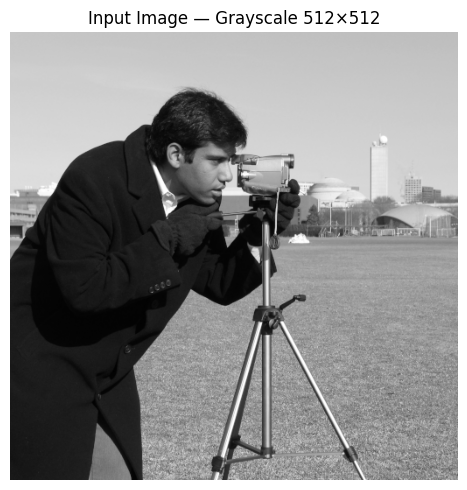

In [34]:
img_raw = data.camera()
BLOCK_SIZE = 8
H, W = img_raw.shape
H_crop = (H // BLOCK_SIZE) * BLOCK_SIZE
W_crop = (W // BLOCK_SIZE) * BLOCK_SIZE

img_array = img_raw[:H_crop, :W_crop].astype(np.float64)

print(f"Original size : {img_raw.shape}")
print(f"Cropped size  : {img_array.shape}  ← both divisible by 8")

plt.figure(figsize=(5, 5))
plt.imshow(img_array, cmap='gray')
plt.title('Input Image — Grayscale 512×512')
plt.axis('off')
plt.tight_layout()
plt.savefig('output_original.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Task 2: Block-wise SVD Function

### How it works

Each 8×8 block is decomposed using SVD:

$$B = U \Sigma V^T = \sum_{i=1}^{8} \sigma_i \cdot \mathbf{u}_i \mathbf{v}_i^T$$

The rank-k reconstruction keeps only the top-k terms:

$$\hat{B}_k = \sum_{i=1}^{k} \sigma_i \cdot \mathbf{u}_i \mathbf{v}_i^T$$

- k=1 → only the single most dominant pattern (very blurry)
- k=8 → perfect reconstruction (all patterns included)

The full image is processed by sliding this block over the entire image in non-overlapping 8×8 tiles.

In [28]:
def compress_block(block, k):
    U, S, VT = np.linalg.svd(block, full_matrices=False)

    reconstructed = (U[:, :k] * S[:k]) @ VT[:k, :]

    return np.clip(reconstructed, 0, 255)

def blockwise_svd_compress(image, k, block_size=8):
    H, W = image.shape
    reconstructed = np.zeros_like(image)

    for row in range(0, H, block_size):
        for col in range(0, W, block_size):
            block = image[row : row+block_size, col : col+block_size]
            reconstructed[row : row+block_size, col : col+block_size] = compress_block(block, k)

    return reconstructed

print("Sanity check on a single 8×8 block:")
print(f"{'k':>4}  {'Block shape':>12}  {'Frob Error':>12}")
test_block = img_array[:8, :8]
for k_test in [1, 4, 8]:
    rec = compress_block(test_block, k_test)
    err = np.linalg.norm(test_block - rec, 'fro')
    print(f"{k_test:>4}  {str(rec.shape):>12}  {err:>12.4f}")

print("\nk=8 error ≈ 0 confirms perfect reconstruction at full rank ✓")

Sanity check on a single 8×8 block:
   k   Block shape    Frob Error
   1        (8, 8)        3.9688
   4        (8, 8)        1.3244
   8        (8, 8)        0.0000

k=8 error ≈ 0 confirms perfect reconstruction at full rank ✓


---
## Task 3: Compression Analysis

### Compression Ratio Formula

For an 8×8 block:
- Original: 64 values
- SVD compressed: k × (8 + 8 + 1) = 17k values
  - U column: 8 values × k columns = 8k
  - Σ diagonal: k values
  - VT row: 8 values × k rows = 8k

$$\text{Compression Ratio} = \frac{64}{17k}$$

Break-even (CR = 1) occurs at k ≈ 3.76, so meaningful compression only exists for k ≤ 3.

### Frobenius Reconstruction Error

$$\|B - \hat{B}_k\|_F = \sqrt{\sum_{i=k+1}^{8} \sigma_i^2}$$

This tells us how much information we lost by discarding the smaller singular values.

### PSNR (Peak Signal-to-Noise Ratio)

$$\text{PSNR} = 20 \cdot \log_{10}\left(\frac{255}{\sqrt{\text{MSE}}}\right)$$

Higher PSNR = better quality. Above 30 dB is generally considered acceptable.

In [29]:
def compression_ratio(k, block_size=8):
    original = block_size * block_size
    retained = k * (block_size + block_size + 1)
    return original / retained


def frobenius_error(original, reconstructed):
    return np.linalg.norm(original - reconstructed, 'fro')


def compute_psnr(original, reconstructed, max_val=255.0):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

k_values           = list(range(1, 9))
comp_ratios        = []
frob_errors        = []
psnr_values        = []
reconstructed_imgs = {}

print(f"{'k':>3}  {'Comp. Ratio':>12}  {'Values/Block':>13}  {'Frob. Error':>12}  {'PSNR (dB)':>10}")
print("─" * 60)

for k in k_values:
    rec = blockwise_svd_compress(img_array, k)
    cr  = compression_ratio(k)
    fe  = frobenius_error(img_array, rec)
    ps  = compute_psnr(img_array, rec)

    comp_ratios.append(cr)
    frob_errors.append(fe)
    psnr_values.append(ps)
    reconstructed_imgs[k] = rec

    Image.fromarray(rec.astype(np.uint8)).save(f'output_k{k}.png')

    retained = k * 17
    print(f"{k:>3}  {cr:>12.4f}  {retained:>13}  {fe:>12.2f}  {ps:>10.2f}")

print("─" * 60)

  k   Comp. Ratio   Values/Block   Frob. Error   PSNR (dB)
────────────────────────────────────────────────────────────
  1        3.7647             17       5141.15       28.09
  2        1.8824             34       2964.31       32.88
  3        1.2549             51       1875.47       36.85
  4        0.9412             68       1220.45       40.59
  5        0.7529             85        738.48       44.95
  6        0.6275            102        375.79       50.82
  7        0.5378            119        130.38       60.01
  8        0.4706            136          0.00      297.64
────────────────────────────────────────────────────────────


---
## Task 4: Visualization

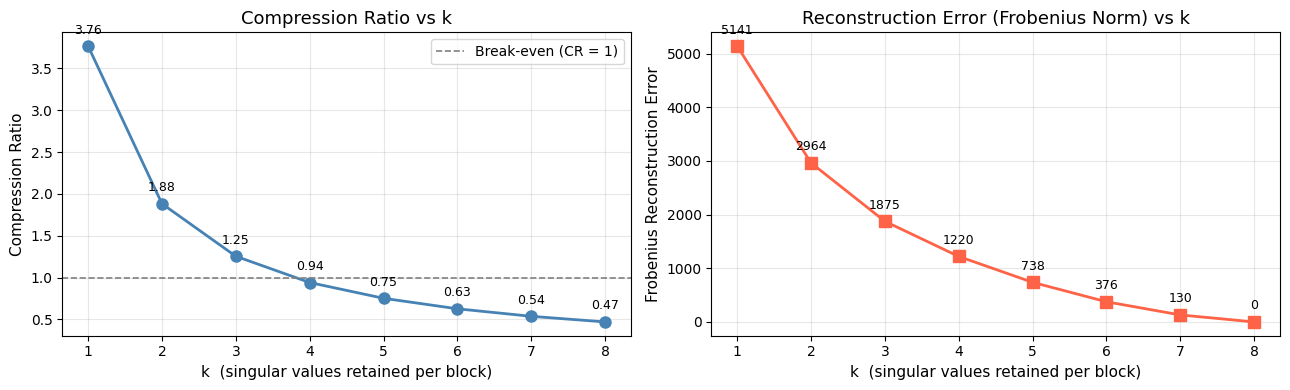

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_values, comp_ratios, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even (CR = 1)')
axes[0].set_xlabel('k  (singular values retained per block)', fontsize=11)
axes[0].set_ylabel('Compression Ratio', fontsize=11)
axes[0].set_title('Compression Ratio vs k', fontsize=13)
axes[0].set_xticks(k_values)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
for x, y in zip(k_values, comp_ratios):
    axes[0].annotate(f'{y:.2f}', (x, y),
                     textcoords='offset points', xytext=(0, 9),
                     ha='center', fontsize=9)

axes[1].plot(k_values, frob_errors, 's-', color='tomato', linewidth=2, markersize=8)
axes[1].set_xlabel('k  (singular values retained per block)', fontsize=11)
axes[1].set_ylabel('Frobenius Reconstruction Error', fontsize=11)
axes[1].set_title('Reconstruction Error (Frobenius Norm) vs k', fontsize=13)
axes[1].set_xticks(k_values)
axes[1].grid(True, alpha=0.3)
for x, y in zip(k_values, frob_errors):
    axes[1].annotate(f'{y:.0f}', (x, y),
                     textcoords='offset points', xytext=(0, 9),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('output_plots_cr_error.png', dpi=120, bbox_inches='tight')
plt.show()

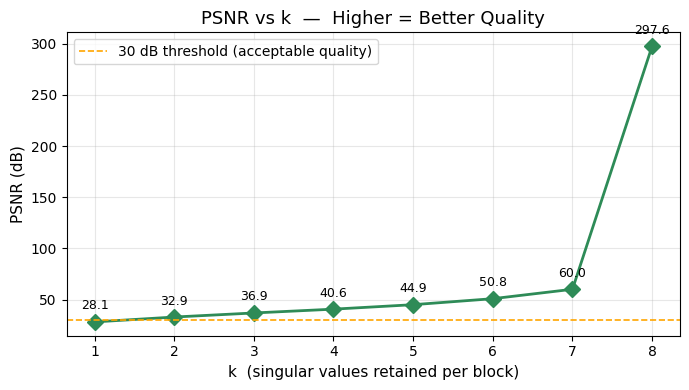

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, psnr_values, 'D-', color='seagreen', linewidth=2, markersize=8)
plt.axhline(y=30, color='orange', linestyle='--', linewidth=1.2, label='30 dB threshold (acceptable quality)')
plt.xlabel('k  (singular values retained per block)', fontsize=11)
plt.ylabel('PSNR (dB)', fontsize=11)
plt.title('PSNR vs k  —  Higher = Better Quality', fontsize=13)
plt.xticks(k_values)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
for x, y in zip(k_values, psnr_values):
    plt.annotate(f'{y:.1f}', (x, y),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('output_psnr.png', dpi=120, bbox_inches='tight')
plt.show()

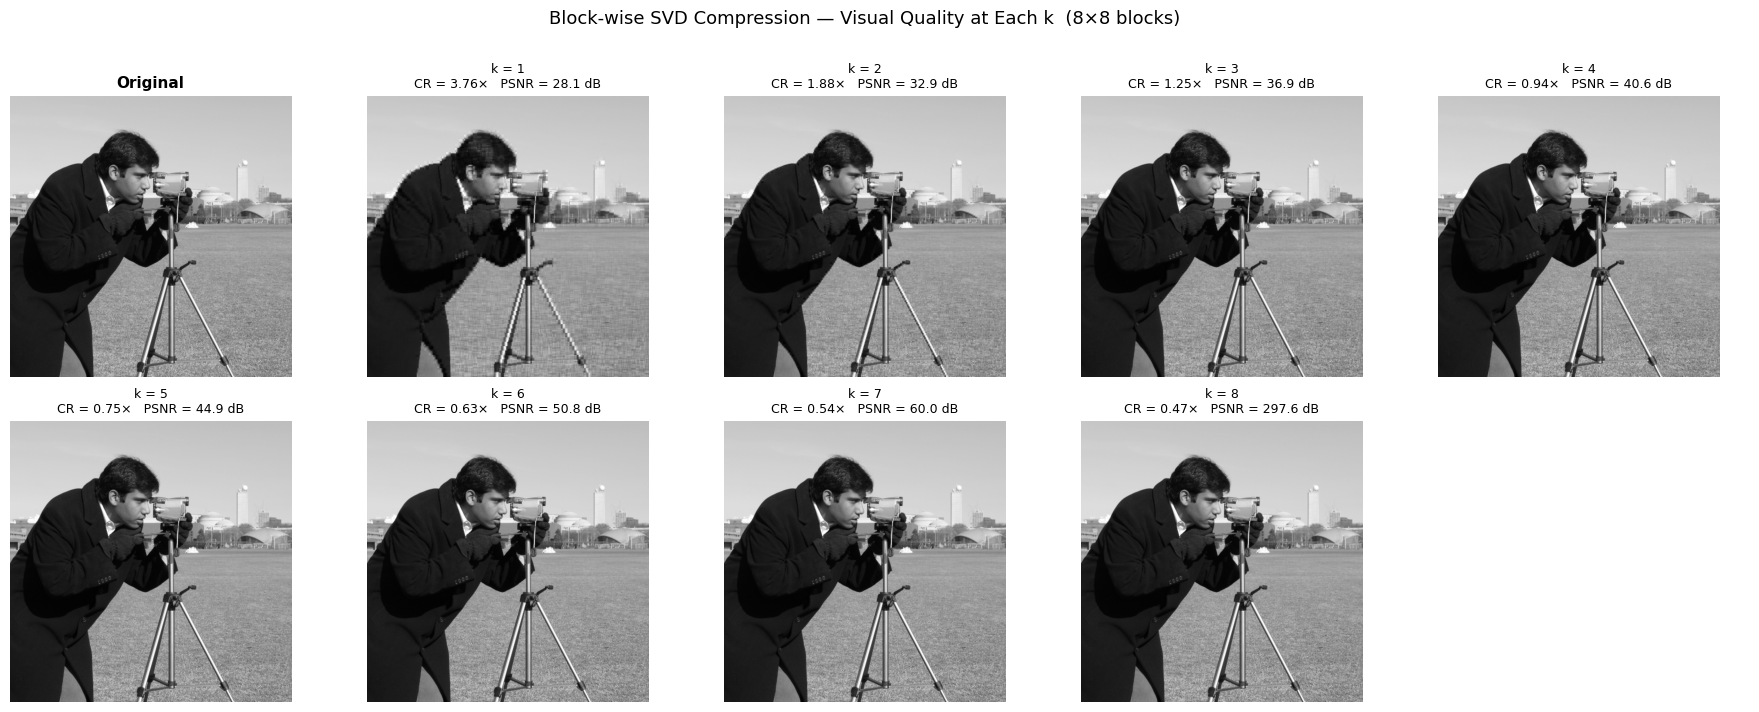

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

axes[0, 0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i, k in enumerate([1, 2, 3, 4], start=1):
    axes[0, i].imshow(reconstructed_imgs[k], cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(
        f'k = {k}\nCR = {comp_ratios[k-1]:.2f}×   PSNR = {psnr_values[k-1]:.1f} dB',
        fontsize=9)
    axes[0, i].axis('off')

for i, k in enumerate([5, 6, 7, 8]):
    axes[1, i].imshow(reconstructed_imgs[k], cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(
        f'k = {k}\nCR = {comp_ratios[k-1]:.2f}×   PSNR = {psnr_values[k-1]:.1f} dB',
        fontsize=9)
    axes[1, i].axis('off')

axes[1, 4].axis('off')  # leave last cell empty

plt.suptitle('Block-wise SVD Compression — Visual Quality at Each k  (8×8 blocks)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output_visual_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 5 : Experiment with Other Block Sizes

We compare 4×4, 8×8, and 16×16 blocks at matched compression ratios.  
Larger blocks give SVD more spatial context per block, generally yielding better quality at the same compression ratio — but produce coarser artifacts when heavily compressed.

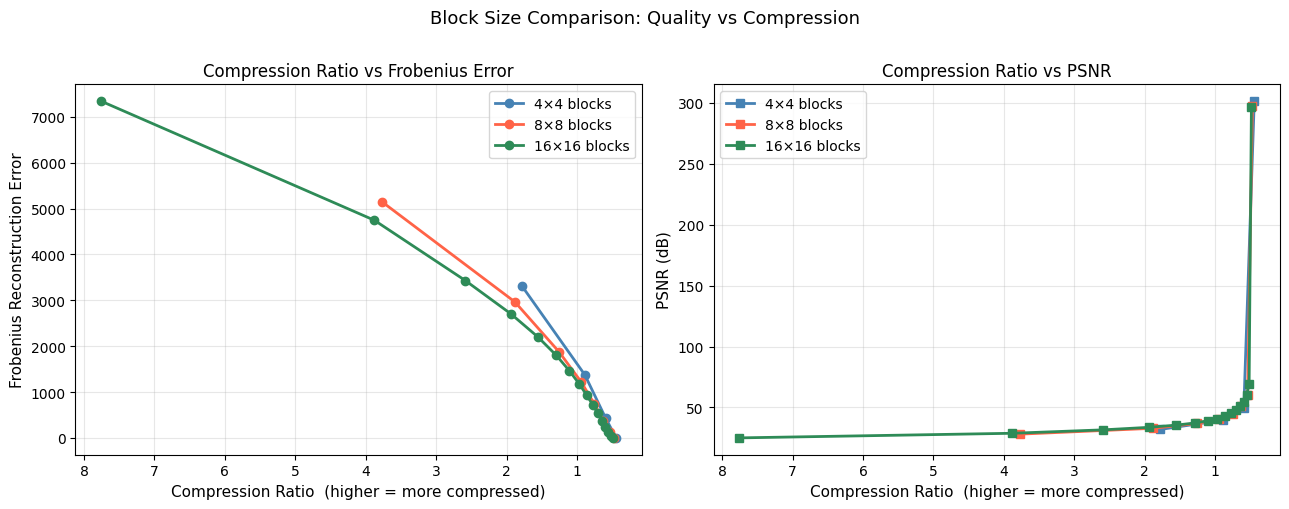

In [33]:
BLOCK_SIZES = [4, 8, 16]
COLORS      = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for bs, color in zip(BLOCK_SIZES, COLORS):
    H, W   = img_array.shape
    img_bs = img_array[:(H // bs)*bs, :(W // bs)*bs]

    crs2, ferrs2, psnrs2 = [], [], []

    for k in range(1, bs + 1):
        rec  = blockwise_svd_compress(img_bs, k, block_size=bs)
        cr   = (bs * bs) / (k * (2 * bs + 1))
        crs2.append(cr)
        ferrs2.append(frobenius_error(img_bs, rec))
        psnrs2.append(compute_psnr(img_bs, rec))

    axes[0].plot(crs2, ferrs2, 'o-', color=color, lw=2, ms=6, label=f'{bs}×{bs} blocks')
    axes[1].plot(crs2, psnrs2, 's-', color=color, lw=2, ms=6, label=f'{bs}×{bs} blocks')

for ax, ylabel, title in zip(
        axes,
        ['Frobenius Reconstruction Error', 'PSNR (dB)'],
        ['Compression Ratio vs Frobenius Error', 'Compression Ratio vs PSNR']):
    ax.set_xlabel('Compression Ratio  (higher = more compressed)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle('Block Size Comparison: Quality vs Compression', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output_block_size_comparison.png', dpi=120, bbox_inches='tight')
plt.show()